# Clustering Standard Errors V2
Julian Hsu
30-May-2026

The purpose of this notebook is to show how ignoring clustering inflates your false positive rate.

**sound byte**

If your experiment randomizes at the cluster level (e.g., cities, user teams) but you analyze at the unit level with classical standard errors, you will reject the null hypothesis far too often — even when there is no true effect. This notebook demonstrates this with simulations: only when standard errors are clustered to match the randomization level does the false positive rate return to the nominal 5%.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

## Data Generating Functions and Estimating Functions

In [2]:
def dgp(n_clusters=200, n_per_cluster=50, impact=0):
    df_cluster = pd.DataFrame({
        'cluster_id': np.arange(n_clusters),
        'w': np.random.choice(2, n_clusters),
        'gp_err': np.random.normal(0, 0.5, n_clusters)
    })

    df = pd.DataFrame({
        'cluster_id': np.repeat(np.arange(n_clusters), n_per_cluster)
    })
    df = df.merge(df_cluster, on='cluster_id')
    df['x'] = np.random.uniform(0, 1, len(df))
    df['y'] = (impact * df['w']
               + df['gp_err']
               + np.random.normal(0, 1, len(df))
               + np.random.uniform(-2, 1) * df['x'])
    return df


def get_pvalue(df, cluster_se=False):
    model = sm.OLS(endog=df['y'], exog=sm.add_constant(df[['w', 'x']]))
    if cluster_se:
        result = model.fit(cov_type='cluster', cov_kwds={'groups': df['cluster_id']})
    else:
        result = model.fit()
    return result.pvalues['w']

## Simulations

In [3]:
np.random.seed(42)
n_sims = 500
n_clusters = 200
n_per_cluster = 50

results = {'standard_se': [], 'clustered_se': []}

for _ in range(n_sims):
    df = dgp(n_clusters=n_clusters, n_per_cluster=n_per_cluster, impact=0)
    results['standard_se'].append(get_pvalue(df, cluster_se=False))
    results['clustered_se'].append(get_pvalue(df, cluster_se=True))

fpr = {k: np.mean(np.array(v) < 0.05) for k, v in results.items()}
print(f"False Positive Rate (Standard SE): {fpr['standard_se']:.3f}")
print(f"False Positive Rate (Clustered SE): {fpr['clustered_se']:.3f}")

False Positive Rate (Standard SE): 0.536
False Positive Rate (Clustered SE): 0.042


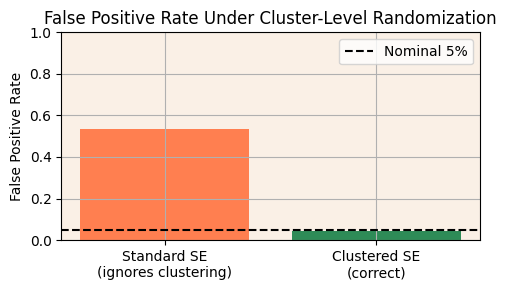

In [4]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 3))

labels = ['Standard SE\n(ignores clustering)', 'Clustered SE\n(correct)']
values = [fpr['standard_se'], fpr['clustered_se']]
colors = ['coral', 'seagreen']

ax.bar(np.arange(2), values, color=colors)
ax.axhline(0.05, color='black', linestyle='--', label='Nominal 5%')
ax.set_xticks(np.arange(2))
ax.set_xticklabels(labels)
ax.set_ylim([0, 1])
ax.set_ylabel('False Positive Rate')
ax.set_title('False Positive Rate Under Cluster-Level Randomization')
ax.legend()
ax.grid()
ax.set_facecolor('linen')
plt.tight_layout()
plt.show()